In [1]:
# 09_backtest.ipynb
# Backtest against 3 real-world case studies
# - Aug 2024 jobs report shock
# - Apr 2025 tariff shock
# - Mar 2026 Iran conflict

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")

# Load saved data
prices        = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
copula_scores = pd.read_csv(f"{data_path}/copula_risk_scores.csv", index_col="Date", parse_dates=True)

returns = prices.pct_change().dropna()

# Define case study windows
CASES = {
    "2024 Jobs Report Shock": {
        "start": "2024-07-01",
        "shock": "2024-08-05",
        "end":   "2024-09-30",
        "color": "orange"
    },
    "2025 Tariff Shock": {
        "start": "2025-03-01",
        "shock": "2025-04-07",
        "end":   "2025-06-30",
        "color": "red"
    },
    "2026 Iran Conflict": {
        "start": "2026-02-01",
        "shock": "2026-03-30",
        "end":   "2026-05-31",
        "color": "darkred"
    }
}

print("Loaded")
print(f"  Prices:       {prices.shape}")
print(f"  Copula scores: {copula_scores.shape}")
print(f"\nCase studies: {list(CASES.keys())}")

Loaded
  Prices:       (2141, 5)
  Copula scores: (2105, 5)

Case studies: ['2024 Jobs Report Shock', '2025 Tariff Shock', '2026 Iran Conflict']


In [2]:
# Analyze asset performance per case study
def analyze_case(case_name, case_info, prices, copula_scores):
    start, shock, end = case_info["start"], case_info["shock"], case_info["end"]

    period_prices = prices.loc[start:end]
    period_risk = copula_scores.loc[start:end]

    # Returns for each ticker relative to period start
    period_returns = (period_prices / period_prices.iloc[0] - 1) * 100

    # Risk score at the shock date
    if shock in period_risk.index.astype(str):
        shock_risk = period_risk.loc[shock, "copula_risk_score"]
        shock_regime = period_risk.loc[shock, "regime_label"]
    else:
        nearest = period_risk.index[period_risk.index.get_indexer([pd.Timestamp(shock)], method="nearest")[0]]
        shock_risk = period_risk.loc[nearest, "copula_risk_score"]
        shock_regime = period_risk.loc[nearest, "regime_label"]

    # First time risk score crossed 0.5 (High Risk) → lead time
    high_risk_dates = period_risk[period_risk["copula_risk_score"] >= 0.5].index
    if len(high_risk_dates) > 0:
        first_alert = high_risk_dates[0]
        lead_days = (pd.Timestamp(shock) - first_alert).days
    else:
        first_alert = None
        lead_days = 0

    print(f"\n{'='*50}")
    print(f"Case: {case_name}")
    print(f"{'='*50}")
    print(f"Shock date: {shock}")
    print(f"Risk score at shock: {shock_risk:.4f} ({shock_regime})")
    print(f"Alert triggered: {first_alert.date() if first_alert is not None else 'none'}")
    print(f"Lead time: {lead_days} days")
    print(f"\nPeriod returns ({start} ~ {end}):")
    print(period_returns.iloc[-1].round(2))

    return {
        "case": case_name,
        "shock_risk": shock_risk,
        "lead_days": lead_days,
        "returns": period_returns.iloc[-1].to_dict()
    }

# Run analysis for all cases
results = []
for case_name, case_info in CASES.items():
    result = analyze_case(case_name, case_info, prices, copula_scores)
    results.append(result)


Case: 2024 Jobs Report Shock
Shock date: 2024-08-05
Risk score at shock: 0.5336 (Normal)
Alert triggered: 2024-08-05
Lead time: 0 days

Period returns (2024-07-01 ~ 2024-09-30):
AAPL     7.62
GOOGL   -9.25
JPM      3.20
MSFT    -5.62
SOXX    -6.27
Name: 2024-09-30 00:00:00, dtype: float64

Case: 2025 Tariff Shock
Shock date: 2025-04-07
Risk score at shock: 0.3774 (Normal)
Alert triggered: 2025-04-09
Lead time: -2 days

Period returns (2025-03-01 ~ 2025-06-30):
AAPL    -13.69
GOOGL     5.77
JPM      11.92
MSFT     28.27
SOXX     19.08
Name: 2025-06-30 00:00:00, dtype: float64

Case: 2026 Iran Conflict
Shock date: 2026-03-30
Risk score at shock: 0.3186 (Normal)
Alert triggered: none
Lead time: 0 days

Period returns (2026-02-01 ~ 2026-05-31):
AAPL     15.79
GOOGL    10.74
JPM      -2.37
MSFT      6.82
SOXX     61.45
Name: 2026-05-29 00:00:00, dtype: float64


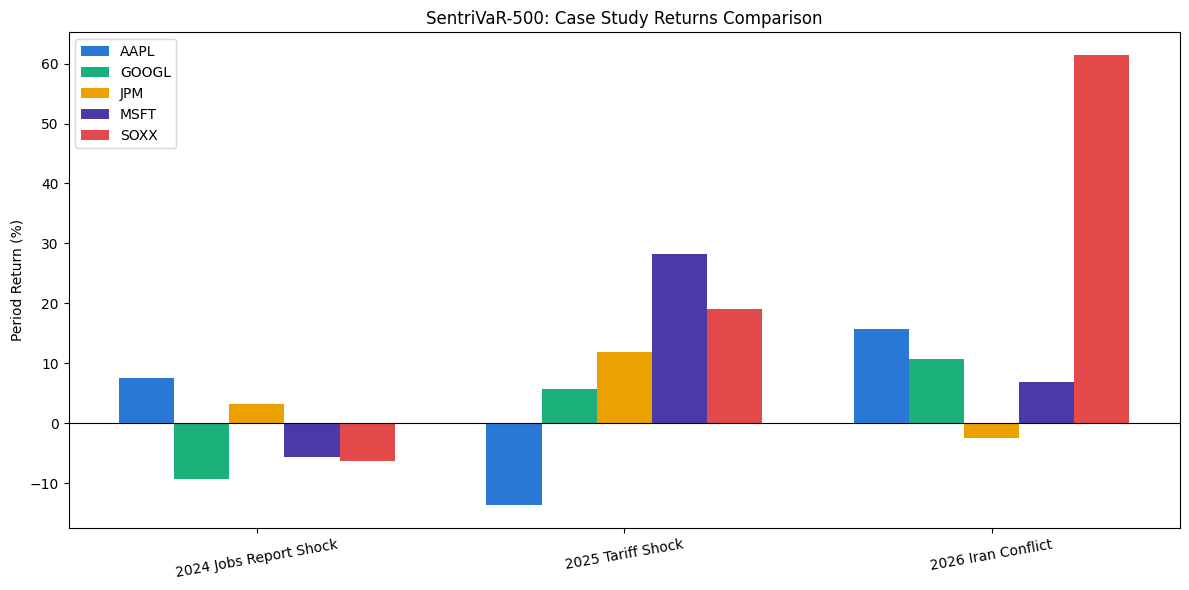

Saved: case_study_comparison.png


In [3]:
# Visualize returns comparison across case studies
fig, ax = plt.subplots(figsize=(12, 6))

case_names = list(CASES.keys())
tickers_list = ["AAPL", "GOOGL", "JPM", "MSFT", "SOXX"]
colors_list = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e34948"]

x = np.arange(len(case_names))
width = 0.15

for i, ticker in enumerate(tickers_list):
    values = [r["returns"][ticker] for r in results]
    ax.bar(x + i*width, values, width, label=ticker, color=colors_list[i])

ax.set_xticks(x + width * 2)
ax.set_xticklabels(case_names, rotation=10)
ax.set_ylabel("Period Return (%)")
ax.set_title("SentriVaR-500: Case Study Returns Comparison")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(f"{data_path}/case_study_comparison.png", dpi=150)
plt.show()
print("Saved: case_study_comparison.png")